# ZQ vs SR3 — feasibility, identification, and the standing premium

The framework's three empirical questions, in the order they gate each other:

1. **Feasibility.** The 25bp lattice has a hard variance ceiling
   (`12.5·w` bp per meeting). When the option surface prices more total width
   than lattice + a generous smear cap, the refit *saturates* and no
   channel-1 signal exists. Where is the feasibility frontier in
   days-to-expiry?
2. **Identification.** Inside the feasible region, are the fitted q's pinned
   by the premiums? The half-tick bootstrap sigma is the measurement error a
   gap must clear — and equal-weight meetings are *exchangeable*, so only the
   N-space CDF (the boundary digitals) is identified at all.
3. **The standing premium.** Against the STRICT ZQ-null tree, the listed
   digitals' gaps measure what the option market pays for everything the
   lattice throws away — the cross-market twin of `tail_rent`. Its level is a
   premium (channel 2, harvest at best); only deviations could ever be
   channel 1.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

DATA = Path("../data/meeting_prob")
mon = pd.read_parquet(DATA / "monitor.parquet")
mon["as_of"] = pd.to_datetime(mon["as_of"])
bd = pd.read_parquet(DATA / "boundaries.parquet")
bd["as_of"] = pd.to_datetime(bd["as_of"])
print(f"monitor rows: {len(mon)}  boundaries: {len(bd)}  "
      f"span {mon['as_of'].min().date()} -> {mon['as_of'].max().date()}")
print(f"contracts: {sorted(mon['symbol'].unique())}")

monitor rows: 1337  boundaries: 7300  span 2024-07-01 -> 2026-07-28
contracts: ['SFRH25', 'SFRH26', 'SFRH27', 'SFRM25', 'SFRM26', 'SFRU25', 'SFRU26', 'SFRZ25', 'SFRZ26']


## 1. The feasibility frontier

In [2]:
mon["dte_bucket"] = pd.cut(mon["days_to_expiry"],
                           [0, 30, 60, 90, 135, 200, 300, 500],
                           labels=["<30", "30-60", "60-90", "90-135",
                                   "135-200", "200-300", "300+"])
feas = (mon.groupby("dte_bucket", observed=True)
        .agg(n=("saturated", "size"),
             saturated=("saturated", "mean"),
             smear_bp=("smear_bp", "median"),
             smear_cap_bp=("smear_cap_bp", "median"),
             event_std_opt=("event_std_opt_bp", "median"),
             event_std_zq=("event_std_zq_bp", "median"),
             ceiling=("lattice_ceiling_bp", "median"),
             total_std_opt=("total_std_opt_bp", "median"),
             rmse_bp=("rmse_bp", "median"))
        .round(2))
print(feas.to_string())
print(f"\noverall saturation rate: {mon['saturated'].mean():.1%}")

              n  saturated  smear_bp  smear_cap_bp  event_std_opt  event_std_zq  ceiling  total_std_opt  rmse_bp
dte_bucket                                                                                                      
<30          19       0.00      4.21         30.65           8.42         11.06    12.50           9.09     0.24
30-60        84       0.02     13.66         31.88          10.06          5.23    12.50          16.20     0.64
60-90       128       0.10     21.07         32.58          10.02          9.47    12.50          23.27     1.03
90-135      225       0.42     30.69         32.77          14.29         12.98    17.68          34.85     1.72
135-200     359       0.94     32.29         32.65          21.65         19.21    21.65          39.36     4.01
200-300     522       1.00     32.61         32.61          27.95         23.69    27.95          42.93     8.81

overall saturation rate: 72.4%


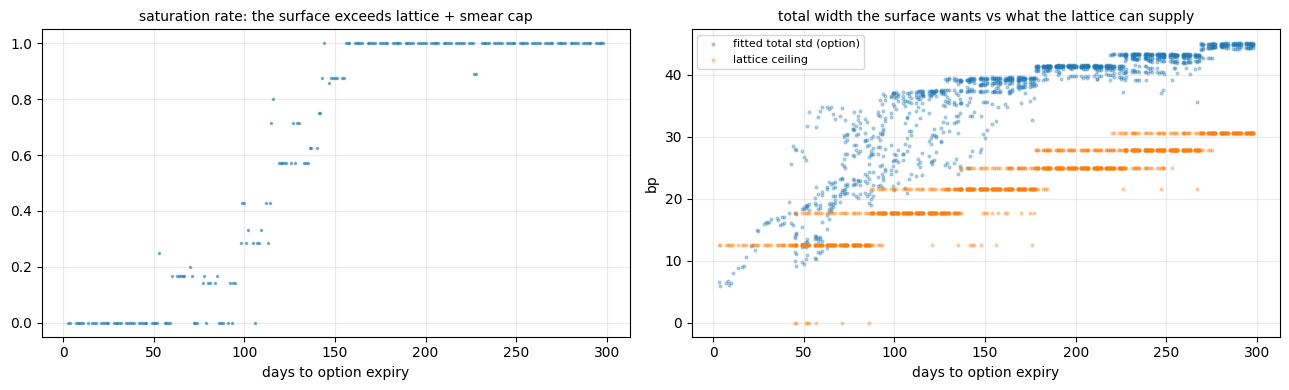

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sat = mon.groupby("days_to_expiry")["saturated"].mean()
axes[0].plot(sat.index, sat.to_numpy(), ".", ms=3, alpha=0.5)
axes[0].set_xlabel("days to option expiry")
axes[0].set_title("saturation rate: the surface exceeds lattice + smear cap",
                  fontsize=10)
axes[0].grid(alpha=0.25)
axes[1].scatter(mon["days_to_expiry"], mon["total_std_opt_bp"], s=4, alpha=0.3,
                label="fitted total std (option)")
axes[1].scatter(mon["days_to_expiry"], mon["lattice_ceiling_bp"], s=4, alpha=0.3,
                label="lattice ceiling")
axes[1].set_xlabel("days to option expiry")
axes[1].set_ylabel("bp")
axes[1].legend(fontsize=8)
axes[1].set_title("total width the surface wants vs what the lattice can supply",
                  fontsize=10)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2. Identification inside the feasible region

In [4]:
ok = mon[~mon["saturated"]].copy()
print(f"unsaturated rows: {len(ok)} ({len(ok) / max(len(mon), 1):.1%})")
qstd_cols = [c for c in ok.columns if c.startswith("qstd_")]
if len(ok) and qstd_cols:
    qs = ok[qstd_cols].stack().dropna()
    print(f"\nbootstrap q_std across meetings (probability points):")
    print((qs * 100).describe().round(2).to_string())
    pgap_cols = [c for c in ok.columns if c.startswith("pgap_")]
    pg = ok[pgap_cols].stack().dropna()
    print(f"\n|p_gap| (probability points):")
    print((pg.abs() * 100).describe().round(2).to_string())
    t_cols = [c for c in ok.columns if c.startswith("tstat_")]
    tt = ok[t_cols].stack().dropna()
    print(f"\n|gap t-stat| vs its own bootstrap sigma:")
    print(tt.abs().describe().round(2).to_string())
    print(f"share with |t| >= 2: {(tt.abs() >= 2).mean():.1%}")

unsaturated rows: 369 (27.6%)

bootstrap q_std across meetings (probability points):
count    601.00
mean       0.31
std        1.69
min        0.00
25%        0.03
50%        0.08
75%        0.22
max       35.55

|p_gap| (probability points):
count    601.00
mean      20.85
std       25.06
min        0.00
25%        5.16
50%       11.12
75%       18.71
max      100.00

|gap t-stat| vs its own bootstrap sigma:
count     595.00
mean      282.54
std       466.58
min         0.11
25%        49.87
50%       126.01
75%       304.01
max      5081.60
share with |t| >= 2: 97.6%


## 3. The standing premium against the strict null

In [5]:
bd["moneyness_bp"] = (bd["boundary_rate"]
                      - bd.merge(mon[["as_of", "symbol", "forward_rate"]],
                                 on=["as_of", "symbol"], how="left")
                      ["forward_rate"]) * 100
prem = (bd.groupby(pd.cut(bd["moneyness_bp"], [-80, -40, -15, 15, 40, 80]),
                   observed=True)["gap"]
        .agg(["mean", "std", "count"]).round(4))
print("listed-minus-null digital gap by moneyness of the boundary:")
print(prem.to_string())

listed-minus-null digital gap by moneyness of the boundary:
                mean     std  count
moneyness_bp                       
(-80, -40]   -0.1170  0.0527   1305
(-40, -15]   -0.0951  0.0634   1300
(-15, 15]     0.0578  0.0909   1653
(15, 40]      0.1696  0.0955   1248
(40, 80]      0.1405  0.0814   1114


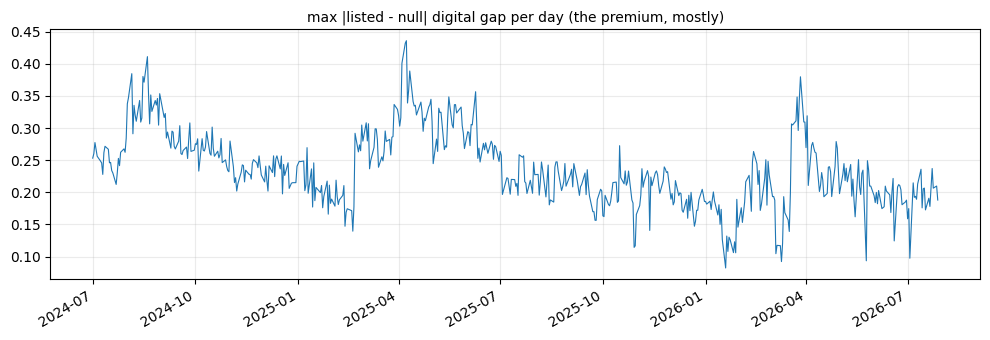

In [6]:
daily_gap = bd.groupby("as_of")["gap"].apply(lambda s: s.abs().max())
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(daily_gap.index, daily_gap.to_numpy(), lw=0.8)
ax.set_title("max |listed - null| digital gap per day (the premium, mostly)",
             fontsize=10)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Channel classification through time

In [7]:
print(mon["channel"].value_counts().to_string())
print("\nby days-to-expiry bucket:")
print(mon.groupby("dte_bucket", observed=True)["channel"]
      .value_counts(normalize=True).round(3).to_string())

channel
channel2    1154
channel1     161
flat          14
thin           8

by days-to-expiry bucket:
dte_bucket  channel 
<30         channel1    0.895
            flat        0.105
30-60       channel2    0.476
            channel1    0.405
            thin        0.071
            flat        0.048
60-90       channel2    0.773
            channel1    0.188
            flat        0.023
            thin        0.016
90-135      channel2    0.738
            channel1    0.240
            flat        0.022
135-200     channel2    0.936
            channel1    0.064
200-300     channel2    0.983
            channel1    0.017


In [8]:
ch = mon.assign(is_c1=mon["channel"] == "channel1")
c1 = (ch.groupby("as_of")["is_c1"].any())
print(f"\ndays with at least one channel-1 classification: {c1.mean():.1%}")
runs = (c1 != c1.shift()).cumsum()
lens = c1.groupby(runs).agg(["first", "size"])
print("channel-1 episode lengths (days):")
print(lens[lens["first"]]["size"].describe().round(1).to_string())


days with at least one channel-1 classification: 24.9%
channel-1 episode lengths (days):
count    45.0
mean      2.9
std       2.8
min       1.0
25%       1.0
50%       2.0
75%       4.0
max      16.0
